# Data Evaluation: User Study

## 0. Setup

In [49]:
import pandas as pd
import matplotlib as mpl

data_df = pd.read_csv('../eval-toolchain/eval-data.csv')
data_df

,participant,p_id,date,group,s_issues_miro,s_issues_pixie,s_issues_correct_miro,s_issues_correct_pixie,p_answered_miro,p_answered_pixie,p_answered_correct_miro,p_answered_correct_pixie
0,2,PA40344,2026-06-29,AP,5,3,NaN,NaN,6,6,NaN,NaN
1,5,MA7125,2026-06-30,AM,2,3,NaN,NaN,2,3,NaN,NaN
2,6,PA45003,2026-06-30,AP,2,1,NaN,NaN,3,4,NaN,NaN
3,4,PB54700,2026-06-30,BP,3,2,NaN,NaN,2,1,NaN,NaN
4,7,MB24145,2026-06-30,BM,3,2,NaN,NaN,1,4,NaN,NaN
5,11,MB50964,NaN,BM,2,4,NaN,NaN,1,2,NaN,NaN
6,10,PA81918,NaN,AP,6,3,NaN,NaN,2,4,NaN,NaN
7,1,MA12534,2026-06-29,AM,3,0,NaN,NaN,2,3,NaN,NaN
8,9,MA95935,2026-06-30,AM,2,0,NaN,NaN,2,2,NaN,NaN
9,8,PB34703,2026-06-30,BP,2,4,NaN,NaN,6,4,NaN,NaN


## 1. Data Exploration

### Total Numbers of Issues/Answered Questions

includes incorrect answers

In [51]:
total_counts_data_cols = [
    's_issues_miro',
    's_issues_pixie',
    'p_answered_miro',
    'p_answered_pixie',
]
total_counts_solvability = [
    's_issues_miro',
    's_issues_pixie',

]
total_counts_pacing = [
    'p_answered_miro',
    'p_answered_pixie',
]
#num_data_df = data_df[num_data_cols]
#num_data_df.index = data_df['p_id']
#plot = num_data_df.plot.pie(subplots=True, figsize=(5, 5))

#### Distribution of Total Number of Identified Issues Across Participants By Tool

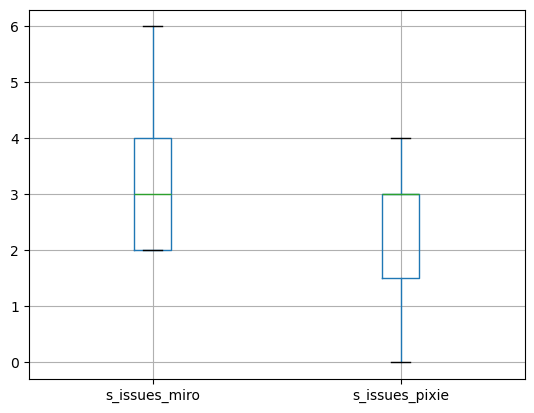

In [52]:
total_solvability_boxplot = data_df.boxplot(column=total_counts_solvability)

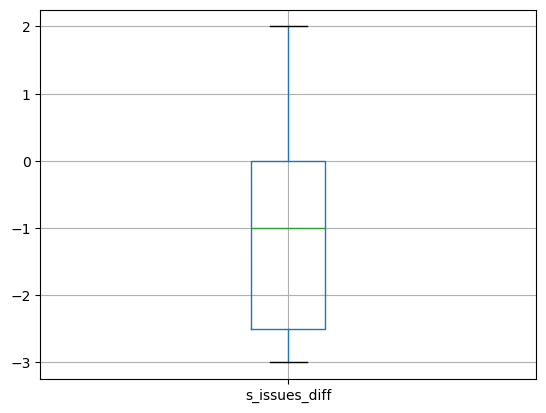

In [60]:
data_df['s_issues_diff'] = data_df['s_issues_pixie'] - data_df['s_issues_miro']
solvability_diff = data_df.boxplot(column=['s_issues_diff'])

### Timeseries

In [56]:
timeseries_data_df = pd.read_csv('../eval-toolchain/time_series/all.csv')
timeseries_data_df

,p_id,group,task,timestamp,tag,note,timedelta
0,PA40344,AP,solvability_pixie,01:27:30,STA,NaN,0
1,PA40344,AP,solvability_pixie,01:27:44,OBS,pathfinding start-room after boss,14
2,PA40344,AP,solvability_pixie,01:28:08,vb,ath blocked to boss,38
3,PA40344,AP,solvability_pixie,01:28:45,OBS,successive pathfinding,75
4,PA40344,AP,solvability_pixie,01:28:56,vb,oftlock 14,86
...,...,...,...,...,...,...,...
373,MB67500,BM,pacing_miro,15:39:55,sec,ion A faster on average,250
374,MB67500,BM,pacing_miro,15:40:25,inc,"eases: 16-18, 21-2 to 21-3",280
375,MB67500,BM,pacing_miro,15:40:45,rem,"rk: need boss key, but same result",300
376,MB67500,BM,pacing_miro,15:41:07,Q4A,miniboss ~~21-3~~ 15,322


#### Timeseries: Issues

In [57]:
issues_data_df = timeseries_data_df[timeseries_data_df['tag'] == 'ISS']
issues_data_df

,p_id,group,task,timestamp,tag,note,timedelta
30,MA7125,AM,solvability_pixie,11:32:16,ISS,missing key between 31 and Boss,71
31,MA7125,AM,solvability_pixie,11:33:16,ISS,12 not reachable,131
34,MA7125,AM,solvability_pixie,11:36:42,ISS,one-directional path 12-11,337
36,MA7125,AM,solvability_miro,11:27:20,ISS,cannot got further than marked path,120
37,MA7125,AM,solvability_miro,11:27:49,ISS,one-directional path 12-15,149
62,PA45003,AP,solvability_pixie,12:27:03,ISS,21-19 not unlockable bc simple key is missing,278
66,PA45003,AP,solvability_miro,12:32:41,ISS,"27 not reachable: 3 simple keys needed, only 1...",136
87,PB54700,BP,solvability_pixie,10:25:37,ISS,can't get to boss key (ability lock),104
89,PB54700,BP,solvability_pixie,10:27:11,ISS,can't get to 12 from 6 bc simple key missing,198
93,PB54700,BP,solvability_miro,10:32:39,ISS,cannot unlock 20-19,0


In [65]:
first_issues_df = issues_data_df.loc[issues_data_df.groupby(['p_id', 'task']).timedelta.idxmin()]
first_issues_df

,p_id,group,task,timestamp,tag,note,timedelta
246,MA12534,AM,solvability_miro,11:21:21,ISS,"hard lock 6, pretty confident",159
36,MA7125,AM,solvability_miro,11:27:20,ISS,cannot got further than marked path,120
30,MA7125,AM,solvability_pixie,11:32:16,ISS,missing key between 31 and Boss,71
279,MA95935,AM,solvability_miro,16:26:50,ISS,not enough bombs 22-23,156
130,MB24145,BM,solvability_miro,01:23:15,ISS,can't unlock boss lock 31-39,114
120,MB24145,BM,solvability_pixie,01:31:06,ISS,hardlock in 6 from highlighting,59
168,MB50964,BM,solvability_miro,11:29:06,ISS,"can get to 11, but not out again -> hardlock",81
157,MB50964,BM,solvability_pixie,11:36:20,ISS,can't get from start to 2,60
352,MB67500,BM,solvability_miro,15:22:45,ISS,can't get to 12,24
345,MB67500,BM,solvability_pixie,15:28:12,ISS,boss node not reachable,6


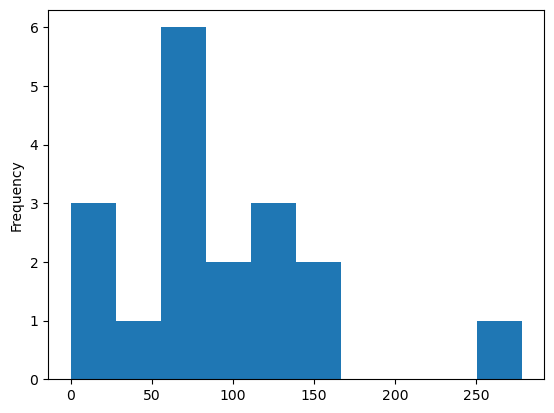

In [ ]:
time_to_first_issue_hist = first_issues_df['timedelta'].plot.hist()

##### Distribution of First Issue Found Events Across Participants By Task

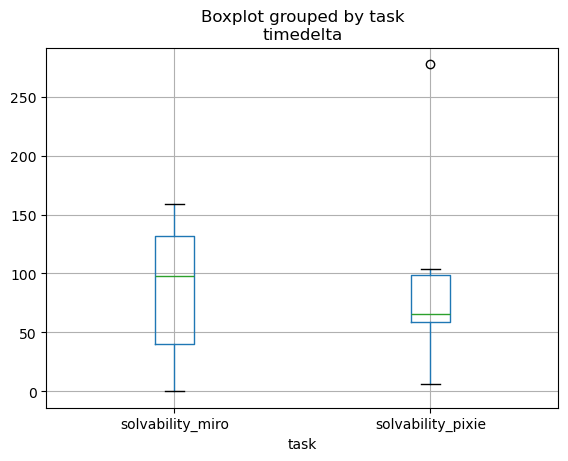

In [71]:
time_to_first_issue_box = first_issues_df.boxplot(by='task', column='timedelta')

##### Distribution of Issue Found Events Across Time

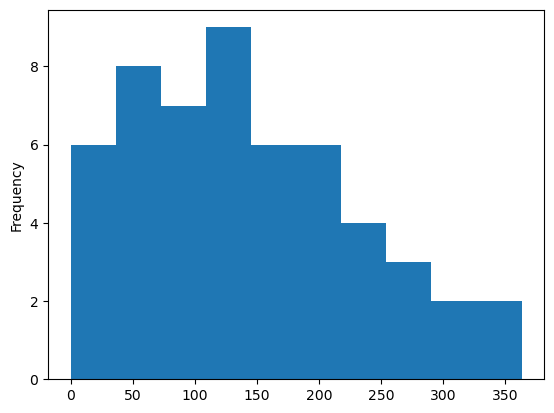

In [58]:
ax2 = issues_data_df['timedelta'].plot.hist()